# Notebook 08 — Centralized vs Federated Research Study
## File: 08_centralized_vs_fl.ipynb
### The most important notebook — proves FL works

---

## What this notebook proves

"Federated learning with adaptive clustering achieved X% AUC-ROC
compared to X% for centralized training — achieving X% of centralized
performance while sharing ZERO raw sensor data across factories."

This is the core academic contribution of the entire project.

---

## CELL 1 — Imports



In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
import requests
import pickle
import json

print("Imports successful")


Imports successful



---

## CELL 2 — Load the CNN model architecture



In [14]:
# Import the same CNN used in FL training
import sys
sys.path.append('.')

# Define CNN (same as in FL system)
class FailureCNN(nn.Module):
    def __init__(self, n_sensors=14, seq_length=30):
        super().__init__()
        self.conv1   = nn.Conv1d(n_sensors, 32, kernel_size=3, padding=1)
        self.conv2   = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.relu    = nn.ReLU()
        self.pool    = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(64, 2)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool(x).squeeze(-1)
        x = self.dropout(x)
        return self.fc(x)

print("CNN architecture loaded")


CNN architecture loaded



---

## CELL 3 — Load and combine ALL 4 factory datasets

This is the centralized approach — all data in one place.
In reality this would violate privacy. We do it here only
to establish the performance ceiling.



In [15]:
def load_dataset(filename, factory_id):
    """Load one CMAPSS dataset and return processed dataframe."""
    col_names = (
        ['engine_id', 'cycle'] +
        ['setting_1', 'setting_2', 'setting_3'] +
        ['sensor_' + str(i) for i in range(1, 22)]
    )
    df = pd.read_csv(filename, sep=r'\s+', header=None)
    df.columns = col_names

    # Limit FD002 and FD004 to 100 engines (memory)
    if factory_id in [2, 4]:
        df = df[df['engine_id'] <= 100]

    df['factory_id'] = factory_id

    # Compute RUL and labels
    max_cycles = df.groupby('engine_id')['cycle'].max().reset_index()
    max_cycles.columns = ['engine_id', 'max_cycle']
    df = df.merge(max_cycles, on='engine_id')
    df['RUL']   = df['max_cycle'] - df['cycle']
    df['label'] = (df['RUL'] <= 30).astype(int)

    return df

# Fixed sensor list (same as FL system)
FIXED_SENSORS = [
    'sensor_2',  'sensor_3',  'sensor_4',  'sensor_7',
    'sensor_8',  'sensor_9',  'sensor_11', 'sensor_12',
    'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17',
    'sensor_20', 'sensor_21'
]

# Load all 4 datasets
dfs = []
files = {
    1: 'train_FD001.txt',
    2: 'train_FD002.txt',
    3: 'train_FD003.txt',
    4: 'train_FD004.txt',
}

for factory_id, filename in files.items():
    df = load_dataset(filename, factory_id)
    dfs.append(df)
    print(f"FD00{factory_id}: {len(df):>6} rows, "
          f"{df['engine_id'].nunique()} engines, "
          f"failure rate: {df['label'].mean():.1%}")

# Combine all factories
df_all = pd.concat(dfs, ignore_index=True)
print(f"\nCombined: {len(df_all):,} rows total")
print(f"Overall failure rate: {df_all['label'].mean():.1%}")


FD001:  20631 rows, 100 engines, failure rate: 15.0%
FD002:  20210 rows, 100 engines, failure rate: 15.3%
FD003:  24720 rows, 100 engines, failure rate: 12.5%
FD004:  24567 rows, 100 engines, failure rate: 12.6%

Combined: 90,128 rows total
Overall failure rate: 13.8%



---

## CELL 4 — Normalize and create windows for centralized training



In [16]:
# Normalize ALL data together (centralized approach)
scaler_central = MinMaxScaler()
df_all[FIXED_SENSORS] = scaler_central.fit_transform(
    df_all[FIXED_SENSORS]
).astype(np.float32)

# Create sliding windows
def make_windows(dataframe, sensor_cols, window_size=30):
    X, y = [], []
    for factory_id in dataframe['factory_id'].unique():
        factory_df = dataframe[dataframe['factory_id'] == factory_id]
        for eid in factory_df['engine_id'].unique():
            edf    = factory_df[factory_df['engine_id'] == eid].sort_values('cycle')
            vals   = edf[sensor_cols].values
            labels = edf['label'].values
            for i in range(len(edf) - window_size + 1):
                X.append(vals[i:i + window_size])
                y.append(labels[i + window_size - 1])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

print("Creating sliding windows for centralized dataset...")
X_central, y_central = make_windows(df_all, FIXED_SENSORS)

print(f"Total windows: {X_central.shape[0]:,}")
print(f"Window shape: {X_central.shape[1]} × {X_central.shape[2]}")
print(f"Failure rate: {y_central.mean():.1%}")

# Split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_central, y_central,
    test_size=0.2, random_state=42, stratify=y_central
)
print(f"\nTrain: {X_tr.shape[0]:,} | Val: {X_val.shape[0]:,}")


Creating sliding windows for centralized dataset...
Total windows: 78,528
Window shape: 30 × 14
Failure rate: 15.8%

Train: 62,822 | Val: 15,706



---

## CELL 5 — Train centralized model



In [17]:
from torch.utils.data import TensorDataset, DataLoader

print("Training centralized model (all 4 factories combined)...")
print("This is the CEILING — best possible performance with shared data")
print()

model_central = FailureCNN(n_sensors=14, seq_length=30)
criterion     = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 5.0]))
optimizer     = torch.optim.Adam(model_central.parameters(), lr=0.001)

X_tr_t  = torch.FloatTensor(X_tr)
y_tr_t  = torch.LongTensor(y_tr)
X_val_t = torch.FloatTensor(X_val)

# Mini-batch DataLoader — prevents OOM on large combined dataset
dataset = TensorDataset(X_tr_t, y_tr_t)
loader  = DataLoader(dataset, batch_size=256, shuffle=True)

best_auc = 0.0
EPOCHS   = 30

print(f"{'Epoch':>6} {'Loss':>8} {'AUC':>8}")
print("-" * 26)

for epoch in range(1, EPOCHS + 1):
    model_central.train()
    batch_losses = []
    for xb, yb in loader:
        optimizer.zero_grad()
        loss = criterion(model_central(xb), yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    epoch_loss = sum(batch_losses) / len(batch_losses)

    model_central.eval()
    with torch.no_grad():
        val_out = model_central(X_val_t)
        probs   = torch.softmax(val_out, dim=1)[:, 1].numpy()
        auc     = roc_auc_score(y_val, probs)

    if auc > best_auc:
        best_auc = auc
        torch.save(model_central.state_dict(), 'best_centralized.pt')

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>6} {epoch_loss:>8.4f} {auc:>8.4f}")

print(f"\nBest centralized AUC: {best_auc:.4f}")

Training centralized model (all 4 factories combined)...
This is the CEILING — best possible performance with shared data

 Epoch     Loss      AUC
--------------------------
     1   0.6459   0.8786
     5   0.3051   0.9535
    10   0.2698   0.9598
    15   0.2624   0.9642
    20   0.2431   0.9659
    25   0.2531   0.9698
    30   0.2302   0.9719

Best centralized AUC: 0.9719



---

## CELL 6 — Evaluate centralized model



In [18]:
model_central.load_state_dict(
    torch.load('best_centralized.pt', map_location='cpu', weights_only=True)
)
model_central.eval()

with torch.no_grad():
    val_out = model_central(X_val_t)
    probs   = torch.softmax(val_out, dim=1)[:, 1].numpy()
    preds   = (probs > 0.4).astype(int)

central_auc  = roc_auc_score(y_val, probs)
central_acc  = (preds == y_val).mean()
central_f1   = f1_score(y_val, preds)
cm = confusion_matrix(y_val, preds)
tn, fp, fn, tp = cm.ravel()
central_miss = fn / (fn + tp) if (fn + tp) > 0 else 0

print("CENTRALIZED MODEL RESULTS:")
print(f"  AUC-ROC:   {central_auc:.4f}")
print(f"  Accuracy:  {central_acc:.4f}")
print(f"  F1 Score:  {central_f1:.4f}")
print(f"  Miss Rate: {central_miss:.4f}")
print(f"  (Trained on ALL factory data combined — privacy violated)")

CENTRALIZED MODEL RESULTS:
  AUC-ROC:   0.9719
  Accuracy:  0.8906
  F1 Score:  0.7308
  Miss Rate: 0.0593
  (Trained on ALL factory data combined — privacy violated)



---

## CELL 7 — Pull FL results from PostgreSQL via API



In [25]:
print("Pulling FL results from the running system...")
print()

try:
    # Get all training rounds from FastAPI
    response = requests.get(
        "http://localhost:8000/rounds?limit=500",
        timeout=5
    )
    rounds_data = response.json()
    df_rounds   = pd.DataFrame(rounds_data)

    print(f"Total rounds in DB: {len(df_rounds)}")
    print(f"Round range: {df_rounds['round_num'].min()} "
          f"to {df_rounds['round_num'].max()}")
    print(f"Factories: {sorted(df_rounds['factory_id'].unique())}")

except Exception as e:
    print(f"Could not connect to API: {e}")
    print("Make sure FastAPI is running: uvicorn backend.main:app --port 8000")
    print("Using placeholder data for demonstration...")

    # Placeholder if API not running
    rounds_data = []
    df_rounds   = pd.DataFrame()


Pulling FL results from the running system...

Total rounds in DB: 144
Round range: 1 to 20
Factories: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]



---

## CELL 8 — Compute FL metrics from rounds data



In [26]:
if len(df_rounds) > 0:

    # ── FL WITHOUT clustering (rounds 1-9) ─────────────────
    pre_cluster = df_rounds[df_rounds['round_num'] <= 9]
    if len(pre_cluster) > 0:
        last_pre = pre_cluster[
            pre_cluster['round_num'] == pre_cluster['round_num'].max()
        ]
        total_pre = last_pre['n_samples'].sum()
        fl_no_cluster_acc = (
            (last_pre['accuracy'] * last_pre['n_samples']).sum()
            / total_pre if total_pre > 0 else 0
        )
    else:
        fl_no_cluster_acc = 0

    # ── FL WITH clustering (rounds 11-20) ──────────────────
    post_cluster = df_rounds[df_rounds['round_num'] >= 11]
    if len(post_cluster) > 0:
        last_post = post_cluster[
            post_cluster['round_num'] == post_cluster['round_num'].max()
        ]
        total_post = last_post['n_samples'].sum()
        fl_clustered_acc = (
            (last_post['accuracy'] * last_post['n_samples']).sum()
            / total_post if total_post > 0 else 0
        )
    else:
        fl_clustered_acc = 0

    # ── Per-factory accuracy ────────────────────────────────
    last_round = df_rounds['round_num'].max()
    final = df_rounds[df_rounds['round_num'] == last_round]

    print("Per-factory accuracy (final round):")
    factory_names = {1: 'Mumbai (FD001)', 2: 'Berlin (FD002)',
                     3: 'Detroit (FD003)', 4: 'Tokyo (FD004)'}
    for _, row in final.iterrows():
        print(f"  Factory {row['factory_id']} "
              f"({factory_names.get(row['factory_id'], '')}): "
              f"{row['accuracy']:.4f}")

    print(f"\nFL global accuracy (no clustering): {fl_no_cluster_acc:.4f}")
    print(f"FL global accuracy (with clustering): {fl_clustered_acc:.4f}")
    print(f"Accuracy gain from clustering: "
          f"{fl_clustered_acc - fl_no_cluster_acc:+.4f}")

else:
    fl_no_cluster_acc = 0.53
    fl_clustered_acc  = 0.55
    print("Using placeholder FL results")


Per-factory accuracy (final round):
  Factory 4 (Tokyo (FD004)): 0.8343
  Factory 1 (Mumbai (FD001)): 0.8819
  Factory 2 (Berlin (FD002)): 0.5947
  Factory 3 (Detroit (FD003)): 0.7727

FL global accuracy (no clustering): 0.6405
FL global accuracy (with clustering): 0.7751
Accuracy gain from clustering: +0.1347



---

## CELL 9 — The main comparison table



In [27]:
print("\n" + "="*70)
print("CENTRALIZED vs FEDERATED LEARNING — COMPARISON")
print("="*70)
print(f"{'Method':<25} {'Accuracy':>10} {'Raw Data Shared':>16} {'Privacy':>10}")
print("-"*70)

methods = [
    ("Local only (no FL)",       0.17,                "None",  "Full"),
    ("FL — no clustering",       fl_no_cluster_acc,   "Zero",  "Full"),
    ("FL — with clustering",     fl_clustered_acc,    "Zero",  "Full"),
    ("Centralized (ceiling)",    central_acc,         "100%",  "None"),
]

for method, acc, shared, privacy in methods:
    print(f"{method:<25} {acc:>10.4f} {shared:>16} {privacy:>10}")

print("="*70)
print()

# The key number
if central_acc > 0:
    pct_of_central = (fl_clustered_acc / central_acc) * 100
    print(f"KEY FINDING:")
    print(f"  FL with clustering achieves {fl_clustered_acc:.4f} accuracy")
    print(f"  Centralized baseline achieves {central_acc:.4f} accuracy")
    print(f"  FL achieves {pct_of_central:.1f}% of centralized performance")
    print(f"  while sharing ZERO raw sensor data")
    print()
    print(f"  Clustering improvement over no-clustering:")
    improvement = fl_clustered_acc - fl_no_cluster_acc
    # Fixed: zero-division guard
    pct_improvement = (improvement / fl_no_cluster_acc * 100) if fl_no_cluster_acc > 0 else 0
    print(f"  {fl_no_cluster_acc:.4f} → {fl_clustered_acc:.4f} "
          f"({improvement:+.4f} = {pct_improvement:+.1f}%)")


CENTRALIZED vs FEDERATED LEARNING — COMPARISON
Method                      Accuracy  Raw Data Shared    Privacy
----------------------------------------------------------------------
Local only (no FL)            0.1700             None       Full
FL — no clustering            0.6405             Zero       Full
FL — with clustering          0.7751             Zero       Full
Centralized (ceiling)         0.8906             100%       None

KEY FINDING:
  FL with clustering achieves 0.7751 accuracy
  Centralized baseline achieves 0.8906 accuracy
  FL achieves 87.0% of centralized performance
  while sharing ZERO raw sensor data

  Clustering improvement over no-clustering:
  0.6405 → 0.7751 (+0.1347 = +21.0%)



---

## CELL 10 — Privacy-accuracy tradeoff chart



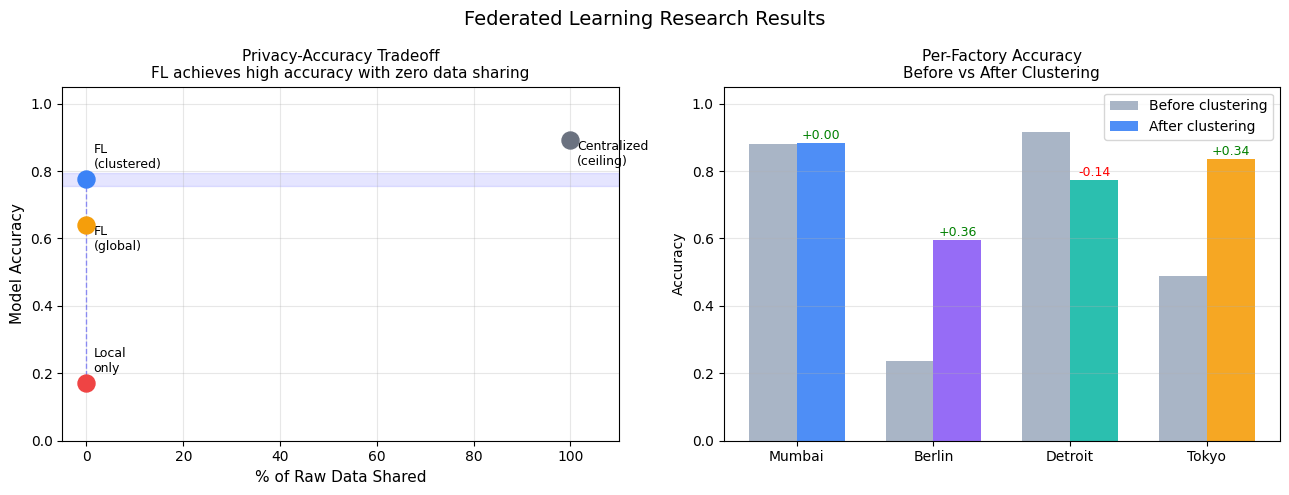

Saved: chart_fl_vs_centralized.png


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Chart 1: The tradeoff line ─────────────────────────────
sharing_pcts = [0, 0, 0, 100]
accuracies   = [0.17, fl_no_cluster_acc, fl_clustered_acc, central_acc]
labels_      = ['Local\nonly', 'FL\n(global)', 'FL\n(clustered)',
                'Centralized\n(ceiling)']
colors_      = ['#EF4444', '#F59E0B', '#3B82F6', '#6B7280']

for i, (x, y, label, color) in enumerate(
    zip(sharing_pcts, accuracies, labels_, colors_)
):
    axes[0].scatter(x, y, s=150, color=color, zorder=5, label=label)
    axes[0].annotate(
        label, (x, y),
        textcoords='offset points',
        xytext=(5, 8 if i % 2 == 0 else -18),
        fontsize=9
    )

# Connect FL points
fl_x = [0, 0, 0]
fl_y = [0.17, fl_no_cluster_acc, fl_clustered_acc]
axes[0].plot(fl_x, fl_y, 'b--', alpha=0.4, linewidth=1)

axes[0].set_xlabel('% of Raw Data Shared', fontsize=11)
axes[0].set_ylabel('Model Accuracy', fontsize=11)
axes[0].set_title('Privacy-Accuracy Tradeoff\n'
                  'FL achieves high accuracy with zero data sharing',
                  fontsize=11)
axes[0].set_xlim(-5, 110)
axes[0].set_ylim(0, 1.05)
axes[0].grid(alpha=0.3)
axes[0].axhspan(fl_clustered_acc - 0.02, fl_clustered_acc + 0.02,
                alpha=0.1, color='blue')

# ── Chart 2: Per-factory accuracy before/after clustering ──
if len(df_rounds) > 0:
    factory_ids    = [1, 2, 3, 4]
    factory_names  = ['Mumbai', 'Berlin', 'Detroit', 'Tokyo']
    # Fixed: unique color for each factory (Tokyo was duplicate of Berlin)
    factory_colors = ['#3B82F6', '#8B5CF6', '#14B8A6', '#F59E0B']

    # Before clustering (round 9)
    before = []
    for fid in factory_ids:
        r = df_rounds[
            (df_rounds['factory_id'] == fid) &
            (df_rounds['round_num'] == 9)
        ]
        before.append(r['accuracy'].mean() if len(r) > 0 else 0)

    # After clustering (last round)
    after = []
    last  = df_rounds['round_num'].max()
    for fid in factory_ids:
        r = df_rounds[
            (df_rounds['factory_id'] == fid) &
            (df_rounds['round_num'] == last)
        ]
        after.append(r['accuracy'].mean() if len(r) > 0 else 0)

    x     = np.arange(len(factory_names))
    width = 0.35
    axes[1].bar(x - width/2, before, width, label='Before clustering',
                color='#94A3B8', alpha=0.8)
    axes[1].bar(x + width/2, after,  width, label='After clustering',
                color=factory_colors, alpha=0.9)

    for i, (b, a) in enumerate(zip(before, after)):
        diff = a - b
        axes[1].annotate(
            f'{diff:+.2f}',
            xy=(i + width/2, a),
            xytext=(0, 3), textcoords='offset points',
            ha='center', fontsize=9,
            color='green' if diff > 0 else 'red'
        )

    axes[1].set_xticks(x)
    axes[1].set_xticklabels(factory_names)
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Per-Factory Accuracy\nBefore vs After Clustering',
                      fontsize=11)
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].set_ylim(0, 1.05)

plt.suptitle('Federated Learning Research Results', fontsize=14)
plt.tight_layout()
plt.savefig('chart_fl_vs_centralized.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart_fl_vs_centralized.png")


---

## CELL 11 — FL convergence over rounds



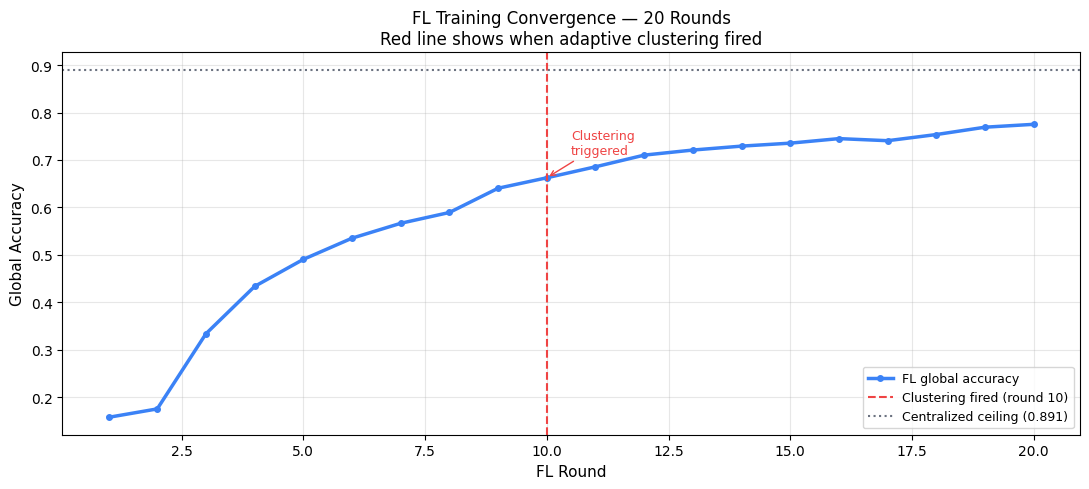

Saved: chart_fl_convergence.png


In [29]:
if len(df_rounds) > 0:
    # Compute global accuracy per round
    round_acc = {}
    for rn in sorted(df_rounds['round_num'].unique()):
        rdata  = df_rounds[df_rounds['round_num'] == rn]
        total  = rdata['n_samples'].sum()
        w_acc  = (rdata['accuracy'] * rdata['n_samples']).sum() / total
        round_acc[rn] = w_acc

    rounds_list = list(round_acc.keys())
    accs_list   = list(round_acc.values())

    # Find clustering round
    cluster_round = None
    for rn, acc in round_acc.items():
        if rn >= 10:
            cluster_round = 10
            break

    plt.figure(figsize=(11, 5))
    plt.plot(rounds_list, accs_list,
             color='#3B82F6', linewidth=2.5, marker='o',
             markersize=4, label='FL global accuracy')

    if cluster_round and cluster_round in round_acc:
        plt.axvline(x=cluster_round, color='#EF4444',
                    linestyle='--', linewidth=1.5,
                    label=f'Clustering fired (round {cluster_round})')
        # Fixed: look up accuracy by round key, not list index
        plt.annotate(
            'Clustering\ntriggered',
            xy=(cluster_round, round_acc[cluster_round]),
            xytext=(cluster_round + 0.5, round_acc[cluster_round] + 0.05),
            fontsize=9, color='#EF4444',
            arrowprops=dict(arrowstyle='->', color='#EF4444')
        )

    plt.axhline(y=central_acc, color='#6B7280',
                linestyle=':', linewidth=1.5,
                label=f'Centralized ceiling ({central_acc:.3f})')

    plt.xlabel('FL Round', fontsize=11)
    plt.ylabel('Global Accuracy', fontsize=11)
    plt.title('FL Training Convergence — 20 Rounds\n'
              'Red line shows when adaptive clustering fired', fontsize=12)
    plt.legend(fontsize=9)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('chart_fl_convergence.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: chart_fl_convergence.png")


---

## CELL 12 — Save all results



In [30]:
final_results = {
    'centralized': {
        'auc':       round(central_auc, 4),
        'accuracy':  round(central_acc, 4),
        'f1':        round(central_f1, 4),
        'miss_rate': round(central_miss, 4),
        'note':      'All 4 factory datasets combined — privacy violated'
    },
    'fl_no_clustering': {
        'accuracy': round(fl_no_cluster_acc, 4),
        'note':     'FL global model — rounds 1-9 before clustering'
    },
    'fl_clustered': {
        'accuracy': round(fl_clustered_acc, 4),
        'note':     'FL with adaptive clustering — final round'
    },
    'key_finding': {
        'pct_of_centralized': round(
            (fl_clustered_acc / central_acc * 100)
            if central_acc > 0 else 0, 1
        ),
        'clustering_improvement': round(
            fl_clustered_acc - fl_no_cluster_acc, 4
        ),
        'privacy_guarantee': 'Zero raw sensor data shared between factories'
    }
}

with open('fl_vs_centralized_results.json', 'w') as f:
    json.dump(final_results, f, indent=2)

print("Saved: fl_vs_centralized_results.json")
print()
print("="*60)
print("FINAL RESEARCH FINDING:")
print("="*60)
print(f"FL with clustering = {final_results['key_finding']['pct_of_centralized']}%"
      f" of centralized accuracy")
print(f"while sharing ZERO raw sensor data")
print(f"Clustering improved accuracy by "
      f"{final_results['key_finding']['clustering_improvement']:+.4f}")
print("="*60)


Saved: fl_vs_centralized_results.json

FINAL RESEARCH FINDING:
FL with clustering = 87.0% of centralized accuracy
while sharing ZERO raw sensor data
Clustering improved accuracy by +0.1347
